# **Taller Práctico: Análisis de Series de Tiempo Financieras como Procesos Estocásticos**

Maestría en Ingeniería Electrónica

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera


En este cuaderno construiremos un marco empírico para analizar datos del mercado de valores, específicamente el índice S&P 500, tratándolo como un proceso estocástico en tiempo discreto $X[n]$.
De acuerdo con la teoría de procesos estocásticos, cada resultado de un experimento se mapea a una colección de variables aleatorias en el tiempo. Aquí, consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.
Para que todas las trayectorias partan del mismo estado inicial, normalizaremos cada año dividiendo todos sus valores por el valor de cierre del primer día del año, asegurando que $X[0]=1$.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# **1. Adquisición y Preparación del Dataset (Data Wrangling)**
Extraeremos el histórico del índice S&P 500 (^GSPC) desde el primero de enero de 1970. Dado que un año financiero típico tiene aproximadamente 252 días de cotización, extraeremos los primeros 250 días de cada año para formar una matriz homogénea de dimensión $M \times N$, donde $M$ es el número de años (realizaciones) y $N=250$ el número de instantes de tiempo.

[*********************100%***********************]  1 of 1 completed


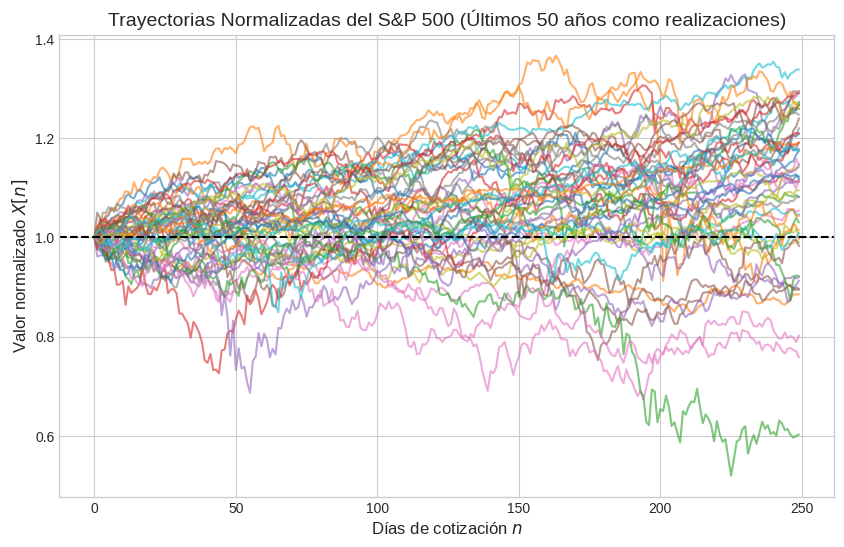

In [11]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
# Si yfinance devuelve un MultiIndex, lo aplanamos
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# 2. Agrupación por año y construcción del ensamble de trayectorias
years = range(1970, 2026)
N_dias = 250 # Fijamos 250 días de cotización por año para tener una matriz uniforme
M = len(years)

# Matriz que contendrá el proceso estocástico X_n
X = np.zeros((M, N_dias))

for i, year in enumerate(years):
    # Extraemos los precios del año correspondiente
    datos = precios[precios.index.year == year].values

    # Verificamos que haya suficientes datos
    if len(datos) > N_dias:
        # Se recordan los datos a N_dias
        X[i, :] = datos[:N_dias]

    elif len(datos) < N_dias: # Si tiene menos de 250 días, rellenamos con el último valor
        # np.pad agrega 0 datos al inicio y N_dias - len(datos) datos al final
        # La opción 'edge' rellena con el último valor encontrado en la serie
        X[i, :] = np.pad(datos, (0, N_dias - len(datos)), 'edge')

    else:
        X[i, :] = datos

    # Normalización: X[n] = Precio[n] / Precio[0]
    X[i, :] = X[i, :]/X[i, 0]

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M-50), M):
    plt.plot(range(N_dias), X[i, :], alpha=0.6, lw=1.5)

plt.title('Trayectorias Normalizadas del S&P 500 (Últimos 50 años como realizaciones)', fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Valor normalizado $X[n]$', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--')
plt.show()

# **Reto 1: Caracterización de Primer Orden (Estimación de PDFs)**
Para un tiempo discreto fijo $n$, $X[n]$ representa una variable aleatoria caracterizada por su función de densidad de probabilidad $f_X​(x,n)$.
Tu tarea:
1. Seleccione los datos del ensamble (la matriz X) para los instantes de tiempo (días) n=1, n=100 y n=200.
2. Estime y grafique la PDF para cada uno de estos días en una misma figura con 3 subgráficos (puedes usar sns.histplot con la opción kde=True).
3. Análisis: Observe las tres gráficas. ¿Qué sucede con la dispersión (varianza) de los posibles valores del índice a medida que avanza el año? Argumenta tu respuesta en una celda de texto.

In [12]:
# Incluya aquí el código del Reto 1


# **Reto 2: Valor Esperado y Varianza del Proceso Estocástico**
El primer momento probabilístico o valor esperado del proceso se define como $\mu[n]=E\{X[n]\}$. Su varianza se define como $\mathrm{var}\{X[n]\}=\mathbf{E}\{(X[n]−\mu[n])^2\}$. La tarea:

1. Calcule empíricamente el valor esperado $\mu[n]$ promediando a través del ensamble (las $M$ realizaciones) para cada uno de los $N$ días.
2. Calcule empíricamente la varianza transversal para cada uno de los $N$ días.
3. Grafique el valor esperado empírico $\mu[n]$ en función de $n$ (días de cotización). Añade una línea de referencia en el nivel base $X[0]=1$.
4. Grafique la varianza empírica en función de $n$ en otro panel.
5. Análisis: Un proceso es Estacionario en Sentido Amplio (WSS) si su valor esperado es constante en el tiempo y su función de autocorrelación depende únicamente de la diferencia de tiempo $\tau$. Basado en las gráficas, ¿el índice S&P 500 puede modelarse como un proceso estocástico WSS? ¿Por qué?

In [13]:
# Incluya aquí el código del Reto 2


# **Reto 3: Función de Autocorrelación y Autocovarianza para $n_1​=100$**

1. Fije el día de referencia $n_1​=100$. Calcule un arreglo con la autocorrelación empírica $R_{XX}​(100,n_2​)$ barriendo todos los días $n_2\in{0,…,249}$.
2. Calcule un arreglo con la autocovarianza empírica $C_{XX}​(100,n_2​)$ para los mismos valores de $n_2$​.
3. Grafique ambas funciones en un mismo plano. Señale con una línea vertical el instante $n_1​=100$.
4. Análisis: ¿Cuál es la relación teórica entre la función de autocovarianza $C_{XX}​(n_1​,n_2​)$ evaluada en $n_1​=n_2​=100$ y la varianza del proceso en ese mismo instante calculada en el Reto 2? Verifique empíricamente si los valores coinciden.

In [14]:
# Incluya aquí el código del Reto 3


# **Reto 4: Matriz de Autocovarianza**
1. Calcule la matriz de autocovarianza empírica completa a partir de la matriz de realizaciones $X$. (Pista: np.cov es útil, pero asegúrese de definir correctamente si las variables están en las filas o en las columnas usando el argumento rowvar). El resultado debe ser una matriz de dimensión $250\times 250$.
2. Grafique esta matriz como un mapa de calor 2D (heatmap). Puede usar plt.imshow, sns.heatmap o plt.pcolormesh.
3. Asegúrate de incluir una barra de colores (colorbar) e identificar correctamente los ejes $n_1​$ y $n_2$​.
4. Análisis: Observe la diagonal principal del mapa de calor (donde $n_1​=n_2$​). ¿Qué estadística del proceso representa esta diagonal y cómo concuerda su evolución de color con la gráfica de varianza que obtuvo en el Reto 2?

In [15]:
# Incluya aquí el código del Reto 4


A diferencia de analizar el precio directamente, en finanzas es común modelar los rendimientos diarios. Definiremos nuestro proceso estocástico X[n] como el rendimiento porcentual del índice en el día n, calculado como la variación porcentual respecto al día anterior:

$X[n]=\frac{Precio[n]-Precio[n-1]}{Precio[n−1]​}\times 100$

Consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.

[*********************100%***********************]  1 of 1 completed


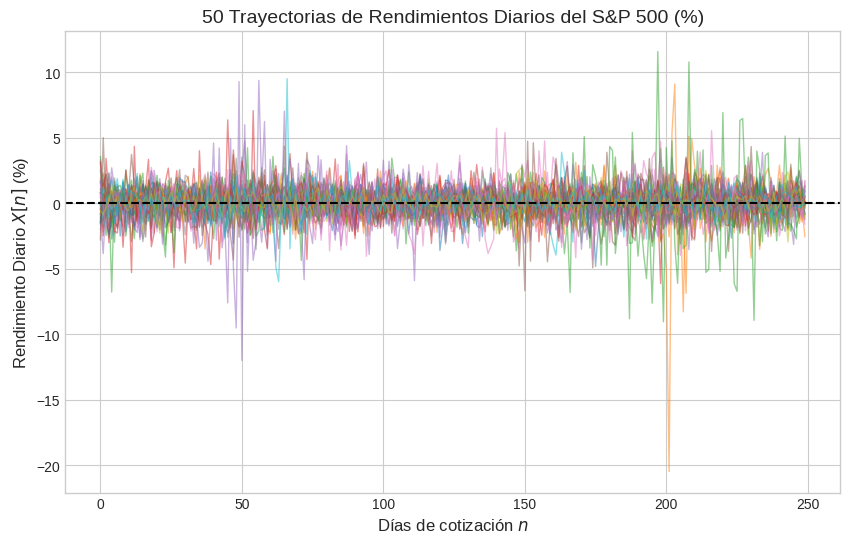

In [16]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# Cálculo de los rendimientos diarios en porcentaje (se elimina el primer valor nulo)
rendimientos = precios.pct_change().dropna() * 100

# 2. Agrupación por año y construcción del ensamble de trayectorias
years = range(1970, 2026)
N_dias = 250 # Fijamos 250 días de cotización por año para tener una matriz uniforme
M = len(years)

# Matriz que contendrá el proceso estocástico X_n (Rendimientos)
X = np.zeros((M, N_dias))

for i, year in enumerate(years):
    # Extraemos los rendimientos del año correspondiente
    datos = rendimientos[rendimientos.index.year == year].values

    # Verificamos que haya suficientes datos
    if len(datos) > N_dias:
        # Se recortan los datos a N_dias
        X[i, :] = datos[:N_dias]

    elif len(datos) < N_dias:
        # Rellenamos con 0 (rendimiento nulo) los días faltantes
        # La opción 'constant' con constant_values=0 agrega ceros al final
        X[i, :] = np.pad(datos, (0, N_dias - len(datos)), 'constant', constant_values=0)

    else:
        X[i, :] = datos

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M-50), M):
    plt.plot(range(N_dias), X[i, :], alpha=0.5, lw=1)

plt.title('50 Trayectorias de Rendimientos Diarios del S&P 500 (%)', fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Rendimiento Diario $X[n]$ (%)', fontsize=12)
plt.axhline(0.0, color='black', linestyle='--')
plt.show()


#**Reto 5**
Repita los Retos 1, 2, 3 y 4 aplicando el código sobre la nueva matriz X (rendimientos) y analise los resultados. ¿Puede decir que este nuevo proceso es (aproximadamente) WSS?

In [17]:
# Incluya aquí el código del Reto 4
